In [3]:
import matplotlib.pyplot as plt
import joblib as jlb

from collections import Counter
from pyclustering.cluster.clarans import clarans
from Customer_dataset import data
processed_data=data.copy()

In [4]:
print(processed_data.tail(1))

     Age  Income_Level  Date_num  Gender_Male  Occupation_Doctor  \
999   38         54931       956            0                  0   

     Occupation_Engineer  Occupation_Entrepreneur  Occupation_Lawyer  \
999                    0                        0                  0   

     Occupation_Manager  Occupation_Nurse  Occupation_Salesperson  \
999                   0                 0                       1   

     Occupation_Teacher  
999                   0  


In [5]:
#data to list vi claran chi chap nhan list
x = processed_data.values.tolist()
print(x[0])

[23, 70541, 2908, 0, 0, 0, 1, 0, 0, 0, 0, 0]


In [6]:
#xay dung model clarans
k = 5
n_local=5
max_nei=4
Clarans_model = clarans(x, number_clusters=k, numlocal=n_local, maxneighbor=max_nei)
Clarans_model.process()

In [7]:
#lấy cluster và medoids
clusters = Clarans_model.get_clusters()
medoids = Clarans_model.get_medoids()

print("Clusters:", clusters)
print("Medoids:", medoids)

Clusters: [[3, 7, 10, 42, 51, 52, 60, 71, 74, 76, 86, 189, 226, 275, 387, 407, 409, 423, 516, 565, 572, 590, 645, 650, 672, 678, 686, 700, 719, 726, 764, 771, 772, 786, 825, 855, 923, 931, 936, 941, 971], [1, 9, 18, 21, 29, 32, 46, 55, 84, 90, 93, 107, 117, 120, 125, 167, 172, 174, 178, 190, 199, 213, 219, 227, 241, 259, 260, 270, 281, 282, 294, 299, 329, 336, 348, 353, 357, 362, 388, 406, 422, 429, 435, 468, 470, 472, 473, 480, 490, 492, 500, 508, 510, 511, 517, 526, 531, 538, 540, 546, 551, 559, 571, 573, 574, 576, 577, 579, 583, 587, 594, 596, 605, 616, 620, 627, 629, 640, 658, 660, 668, 681, 688, 694, 696, 697, 706, 725, 744, 751, 756, 758, 767, 773, 789, 797, 800, 806, 810, 815, 818, 821, 824, 834, 838, 843, 849, 854, 859, 877, 878, 882, 887, 890, 891, 893, 917, 918, 919, 933, 937, 943, 948, 954, 955, 986, 999], [0, 2, 5, 6, 12, 20, 26, 36, 37, 39, 40, 41, 45, 47, 54, 58, 65, 66, 69, 72, 75, 77, 80, 85, 88, 91, 94, 96, 100, 113, 114, 115, 116, 118, 122, 124, 129, 135, 140, 145, 14

In [8]:
#gắn nhãn cluster đã có vào df
labels = [0] * len(data)

for cluster_id, cluster in enumerate(clusters):
    for index in cluster:
        labels[index] = cluster_id

processed_data['cluster'] = labels
print(processed_data.head(1))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

   Age  Income_Level  Date_num  Gender_Male  Occupation_Doctor  \
0   23         70541      2908            0                  0   

   Occupation_Engineer  Occupation_Entrepreneur  Occupation_Lawyer  \
0                    0                        1                  0   

   Occupation_Manager  Occupation_Nurse  Occupation_Salesperson  \
0                   0                 0                       0   

   Occupation_Teacher  cluster  
0                   0        2  

Kích thước clusters: Counter({3: 372, 2: 263, 4: 197, 1: 127, 0: 41})

2 clusters lớn nhất: [(3, 372), (2, 263)]


In [9]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [10]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

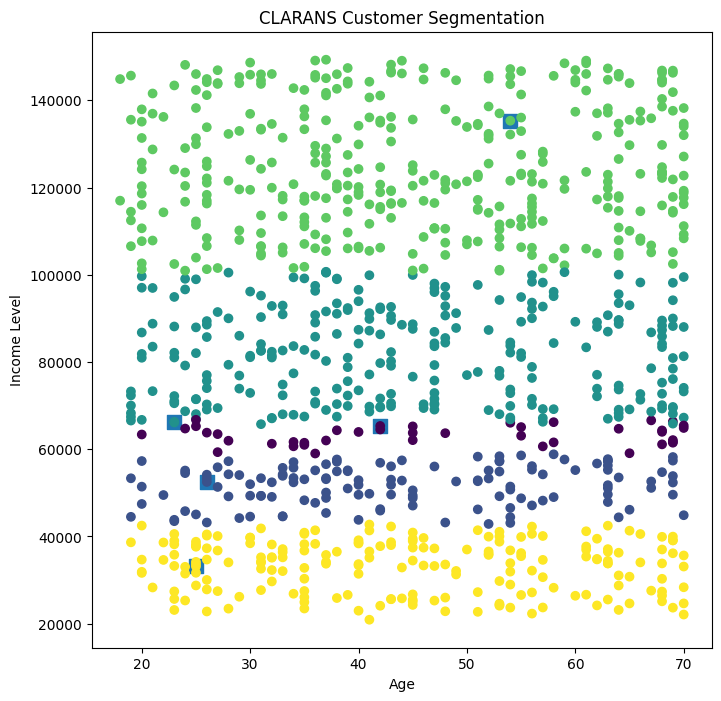

In [11]:
#hien thi model
medoid_points = processed_data.iloc[medoids]

plt.figure(figsize=(8,8))

plt.scatter(medoid_points['Age'],
            medoid_points['Income_Level'],
            marker='s',
            s=100
            )

plt.scatter(processed_data['Age'],
            processed_data['Income_Level'],
            c=processed_data['cluster'])

plt.xlabel("Age")
plt.ylabel("Income Level")
plt.title("CLARANS Customer Segmentation")

plt.show()